# WRAPIFY.ipynb
### Wrapify will take your Spotify data and give you many of the same metrics that you can expect to receive from a typical Spotify Wrapped, including:
- Top 20 songs of all time
- Top 10 songs for each year
- Top 20 artists of all time
- Top 10 artists of each year
- Top 10 albums of all time
- Top 5 albums of each year
- Total minutes, hours, and days listened for all time 
- Total minutes, hours, and days listened each year

#### Each individual metric has an associated table and bar plot so you can visualize your spotify data

 ### This is a passion project that I am still actively working on, but all basic functions have been completed! The following functionality will hopefully be added in the future:

#### search for a specific song for the following results:
- how many listens you had all time
- How many listens did you have each year, with a visual graph
- How many times have you skipped each year + graph
- How many times have you skipped all time

#### search for a specific artist for the following results:
- how many listens you had all time
- How many listens did you have each year, with a visual graph
- How many individual songs have you listened to by them
- a graph showing which songs got replayed the most
- How many times have you skipped each year + graph
- How many times have you skipped all time

#### What genre is most popular with the user?
- include visuals to show which genres are most listened to
- if possible, list a song's genre alongside its artist and album
- if possible, list an artist's genre

In [101]:
import os
import pandas as pd
import seaborn as sns

# for data visualizations
sns.set_theme()
sns.set_palette("deep")

folder = 'Spotify Extended Streaming History/Streaming History'  # folder containing JSON files
#---------------------------------------------------------------------------------
# The following code is meant to load a series of JSON files from one folder, 
# concatenate them all together, remove rows with null values, and save them as 
# an entirely new csv file that can then be used for data queries.
#---------------------------------------------------------------------------------
def merge_json_files(folder):
    merged_data = pd.DataFrame()

    # ensure folder exists
    if not os.path.isdir(folder):
        print(f"Error: Folder '{folder}' not found.")
        return

    # iterate through all files in the folder
    for filename in os.listdir(folder):
        if filename.endswith('.json'): # ensure it ends in .json
            filepath = os.path.join(folder, filename)
            try:
                with open(filepath, encoding='utf-8') as f:
                    data = pd.read_json(f)
                    merged_data = pd.concat([merged_data, data], ignore_index=True) 
            except ValueError as e:
                print(f"Warning: failed to read {filename}: {e}") # exception, failure to read json files
        if merged_data.empty:
            print(f"No JSON rows found in '{folder}'.") # catch to say there are no rows
            return      
        
        # remove any rows without a track name
        cleaned_data = merged_data.dropna(subset=['master_metadata_track_name'])

        # I don't want any of these keys in the final dataset
        keys_to_remove = [
            "platform", "conn_country", "ip_addr", "episode_name", "episode_show_name", 
            "spotify_episode_uri","audiobook_title", "audiobook_uri", "audiobook_chapter_uri", 
            "audiobook_chapter_title", "incognito_mode", "offline_timestamp"
            ]
        for key in keys_to_remove:
            cleaned_data.pop(key)

        # renaming columns for better readability
        cleaned_data = cleaned_data.rename(columns={ 
            'master_metadata_track_name': 'song_title',
            'master_metadata_album_artist_name': 'artist_name',
            'master_metadata_album_album_name': 'album_name',
            'spotify_track_uri': 'track_url'
        })

        # Keeps rows where ms_played is between 20000 and 900000
        # songs outside of this range are removed
        cleaned_data = cleaned_data[cleaned_data['ms_played'].between(20000, 900000)]

        # replace '$' with 'S' since it gets misread by the parser
        cleaned_data['song_title'] = cleaned_data['song_title'].astype(str).str.replace('$', 'S', regex=False)
        cleaned_data['album_name'] = cleaned_data['album_name'].astype(str).str.replace('$', 'S', regex=False)
        cleaned_data['artist_name'] = cleaned_data['artist_name'].astype(str).str.replace('$', 'S', regex=False)

    # remove null values and save merged DataFrame to JSON file (pretty formatted)
    cleaned_data.to_csv('streaming_history.csv', index=False)
    print(f"Merged {len(cleaned_data)} total rows from {folder}/")

# run the function
merge_json_files(folder)

Merged 64524 total rows from Spotify Extended Streaming History/Streaming History/


# Top 20 tracks and artists

In [102]:
#---------------------------------------------------------------------------------
# The following code will produce the most listened to songs, artists, and albums of all time
#---------------------------------------------------------------------------------
with open('streaming_history.csv', encoding='utf-8') as f:
    data = pd.read_csv(f)

    top_tracks_summary = ( # ensure a song has the same artist and album name before adding it to the count
        data.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(20)
    )
            
    top_artists_summary = (
        data.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(20)
    )

    top_albums_summary = ( # ensure an album has the same artist before adding it to the count
        data.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    # calculate the total minutes, hours, and days played
    total_ms_played = data['ms_played'].sum()
    total_minutes = (total_ms_played / 1000) / 60
    total_minutes = total_minutes.astype(int)
    total_hours = int(total_minutes / 60)
    total_days = int(total_hours / 24)

## Total time listened for all time

In [103]:
print(
    "==================================================================================\n"
    "You've enjoyed music for a total of", total_minutes, "minutes, or", total_hours, "hours, or ", total_days, "days \n"
    "=================================================================================="
)

You've enjoyed music for a total of 200816 minutes, or 3346 hours, or  139 days 


## Top 20 songs

,song_title,album_name,play_count,artist
0,Stand By You,Wildfire,171,Rachel Platten
1,The Sound of Silence,Immortalized,137,Disturbed
2,Chocolate,The 1975,130,The 1975
3,Starlight,Black Holes and Revelations,126,Muse
4,Revolt,Drones,123,Muse
5,The Only Hope for Me Is You,Danger Days: The True Lives of the Fabulous Ki...,114,My Chemical Romance
6,Undertale (Music Box),Undertale (Music Box),114,Jayn
7,United States of Eurasia (+Collateral Damage),The Resistance,113,Muse
8,Monkey Tree - UK Mix,Very Good Bad Thing,112,Mother Mother
9,High School,Darling,110,SayWeCanFly


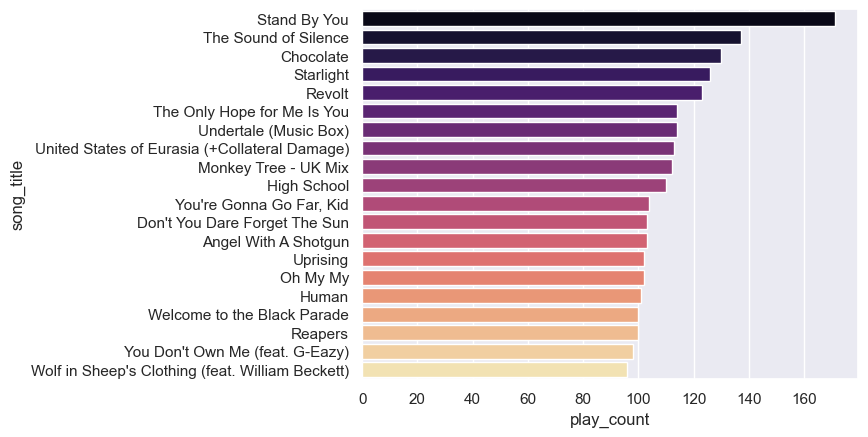

In [104]:
# print a bar plot including the top 20 tracks of all time
sns.barplot(x="play_count", y="song_title", data=top_tracks_summary,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 20 tracks of all time
top_tracks_summary_anagram = top_tracks_summary.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_summary_anagram.head(20)

## Top 20 artists

,artist_name,play count
0,Muse,2973
1,Twenty One Pilots,2153
2,One Direction,1747
3,Panic! At The Disco,1444
4,My Chemical Romance,1439
5,Imagine Dragons,1414
6,Ghost,1365
7,Bleachers,947
8,Halsey,881
9,Lorde,809


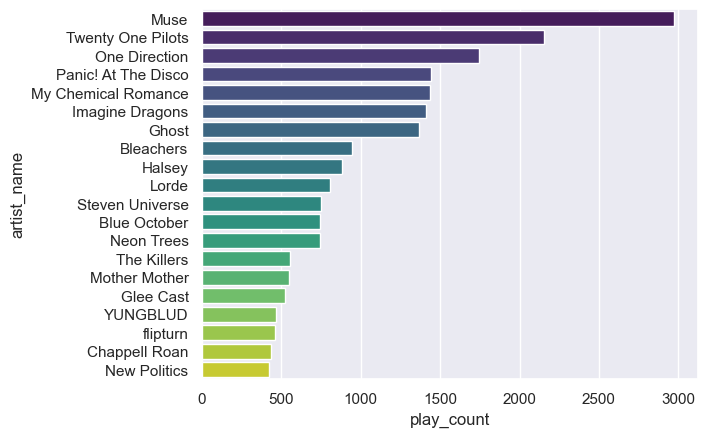

In [105]:
# print a bar plot including the top 20 tracks of all time
sns.barplot(x="play_count", y="artist_name", data=top_artists_summary,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 20 tracks of all time
top_artists_summary_anagram = top_artists_summary.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_summary_anagram.head(20)

## Top 10 Albums

,album_name,play_count,artist name
0,"Steven Universe, Vol. 1 (Original Soundtrack)",656,Steven Universe
1,Death of a Bachelor,642,Panic! At The Disco
2,Danger Days: The True Lives of the Fabulous Ki...,587,My Chemical Romance
3,Smoke + Mirrors,583,Imagine Dragons
4,Black Holes and Revelations,572,Muse
5,Blurryface,572,Twenty One Pilots
6,The Resistance,552,Muse
7,Twenty One Pilots,536,Twenty One Pilots
8,The Black Parade,531,My Chemical Romance
9,BADLANDS,511,Halsey


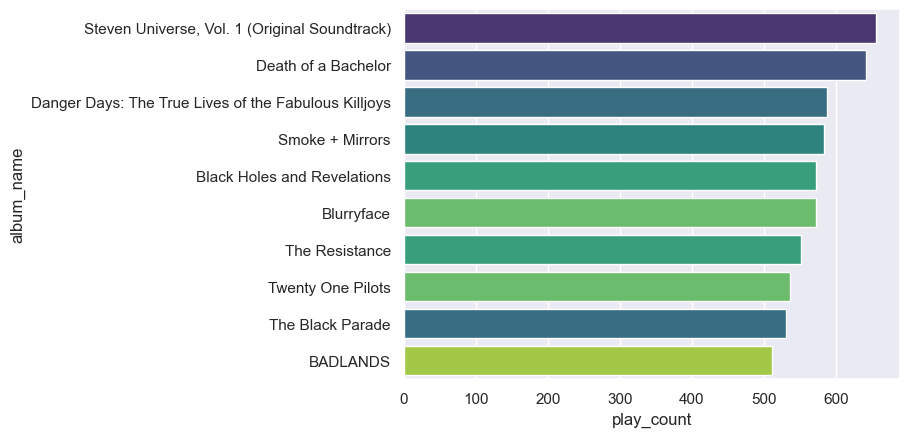

In [106]:
# print a bar plot including the top 10 Albums of all time
sns.barplot(x="play_count", y="album_name", data=top_albums_summary,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 20 tracks of all time
top_albums_summary_anagram = top_albums_summary.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_summary_anagram.head(10)

## Listening trends by year

In [107]:
#---------------------------------------------------------------------------------
# The following code will produce the most listened to songs, artists, and albums of each year
#---------------------------------------------------------------------------------
with open('streaming_history.csv', encoding='utf-8') as f:
    data = pd.read_csv(f)

    # dataset for 2016 listening patterns
    data_2016 = data[data['ts'].between('2016-01-00T00:00:00Z', '2016-12-31T23:59:59Z')]
    top_tracks_2016 = (
        data_2016.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2016 = (
        data_2016.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2016 = (
        data_2016.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2016 = data_2016['ms_played'].sum()
    minutes_2016 = (ms_played_2016 / 1000) / 60
    minutes_2016 = minutes_2016.astype(int)
    hours_2016 = int(minutes_2016 / 60)
    days_2016 = int(hours_2016 / 24)

    # dataset for 2017 listening patterns
    data_2017 = data[data['ts'].between('2017-01-00T00:00:00Z', '2017-12-31T23:59:59Z')]
    top_tracks_2017 = (
        data_2017.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2017 = (
        data_2017.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2017 = (
        data_2017.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2017 = data_2017['ms_played'].sum()
    minutes_2017 = (ms_played_2017 / 1000) / 60
    minutes_2017 = minutes_2017.astype(int)
    hours_2017 = int(minutes_2017 / 60)
    days_2017 = int(hours_2017 / 24)

    # dataset for 2018 listening patterns
    data_2018 = data[data['ts'].between('2018-01-00T00:00:00Z', '2018-12-31T23:59:59Z')]
    top_tracks_2018 = (
        data_2018.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2018 = (
        data_2018.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2018 = (
        data_2018.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2018 = data_2018['ms_played'].sum()
    minutes_2018 = (ms_played_2018 / 1000) / 60
    minutes_2018 = minutes_2018.astype(int)
    hours_2018 = int(minutes_2018 / 60)
    days_2018 = int(hours_2018 / 24)

    # dataset for 2019 listening patterns
    data_2019 = data[data['ts'].between('2019-01-00T00:00:00Z', '2019-12-31T23:59:59Z')]
    top_tracks_2019 = (
        data_2019.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2019 = (
        data_2019.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    top_albums_2019 = (
        data_2019.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2019 = data_2019['ms_played'].sum()
    minutes_2019 = (ms_played_2019 / 1000) / 60
    minutes_2019 = minutes_2019.astype(int)
    hours_2019 = int(minutes_2019 / 60)
    days_2019 = int(hours_2019 / 24)

    # dataset for 2020 listening patterns
    data_2020 = data[data['ts'].between('2020-01-00T00:00:00Z', '2020-12-31T23:59:59Z')]
    top_tracks_2020 = (
        data_2020.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2020 = (
        data_2020.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2020 = (
        data_2020.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2020 = data_2020['ms_played'].sum()
    minutes_2020 = (ms_played_2020 / 1000) / 60
    minutes_2020 = minutes_2020.astype(int)
    hours_2020 = int(minutes_2020 / 60)
    days_2020 = int(hours_2020 / 24)

    # dataset for 2021 listening patterns
    data_2021 = data[data['ts'].between('2021-01-00T00:00:00Z', '2021-12-31T23:59:59Z')]
    top_tracks_2021 = (
        data_2021.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2021 = (
        data_2021.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2021 = (
        data_2021.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2021 = data_2021['ms_played'].sum()
    minutes_2021 = (ms_played_2021 / 1000) / 60
    minutes_2021 = minutes_2021.astype(int)
    hours_2021 = int(minutes_2021 / 60)
    days_2021 = int(hours_2021 / 24)

    # dataset for 2022 listening patterns
    data_2022 = data[data['ts'].between('2022-01-00T00:00:00Z', '2022-12-31T23:59:59Z')]
    top_tracks_2022 = (
        data_2022.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2022 = (
        data_2022.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2022 = (
        data_2022.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2022 = data_2022['ms_played'].sum()
    minutes_2022 = (ms_played_2022 / 1000) / 60
    minutes_2022 = minutes_2022.astype(int)
    hours_2022 = int(minutes_2022 / 60)
    days_2022 = int(hours_2022 / 24)

    # dataset for 2023 listening patterns
    data_2023 = data[data['ts'].between('2023-01-00T00:00:00Z', '2023-12-31T23:59:59Z')]
    top_tracks_2023 = (
        data_2023.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2023 = (
        data_2023.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2023 = (
        data_2023.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2023 = data_2023['ms_played'].sum()
    minutes_2023 = (ms_played_2023 / 1000) / 60
    minutes_2023 = minutes_2023.astype(int)
    hours_2023 = int(minutes_2023 / 60)
    days_2023 = int(hours_2023 / 24)

    # dataset for 2024 listening patterns
    data_2024 = data[data['ts'].between('2024-01-00T00:00:00Z', '2024-12-31T23:59:59Z')]
    top_tracks_2024 = (
        data_2024.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    top_artists_2024 = (
        data_2024.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2024 = (
        data_2024.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2024 = data_2024['ms_played'].sum()
    minutes_2024 = (ms_played_2024 / 1000) / 60
    minutes_2024 = minutes_2024.astype(int)
    hours_2024 = int(minutes_2024 / 60)
    days_2024 = int(hours_2024 / 24)

    # dataset for 2025 listening patterns
    data_2025 = data[data['ts'].between('2025-01-00T00:00:00Z', '2025-12-31T23:59:59Z')]
    top_tracks_2025 = (
        data_2025.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2025 = (
        data_2025.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2025 = (
        data_2025.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2025 = data_2025['ms_played'].sum()
    minutes_2025 = (ms_played_2025 / 1000) / 60
    minutes_2025 = minutes_2025.astype(int)
    hours_2025 = int(minutes_2025 / 60)
    days_2025 = int(hours_2025 / 24)

## Total Hours Listened by Year

<Axes: xlabel='year', ylabel='hours'>

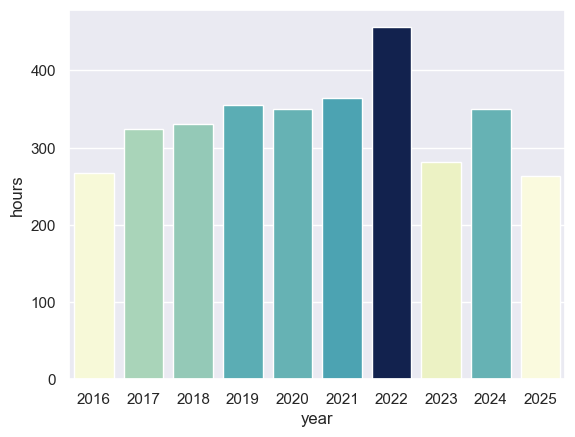

In [109]:
# Bar plot to show hours listened to each year
ms_by_year = {
    'year': ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
    'hours': [hours_2016, hours_2017, hours_2018, hours_2019, hours_2020, hours_2021, hours_2022, hours_2023, hours_2024, hours_2025]
    }
ms_df = pd.DataFrame(ms_by_year)
sns.barplot(x="year", y="hours", data=ms_df,
            label="Total", palette="YlGnBu", hue="hours", legend=False)

## 2016

In [ ]:
print(
    "==================================================================================\n"
    "In 2016, you've enjoyed music for a total of", minutes_2016, "minutes, or", hours_2016, "hours, or ", days_2016, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2016
sns.barplot(x="play_count", y="song_title", data=top_tracks_2016,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2016
top_tracks_2016_anagram = top_tracks_2016.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2016_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2016
sns.barplot(x="play_count", y="artist_name", data=top_artists_2016,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2016
top_artists_2016_anagram = top_artists_2016.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2016_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2016
sns.barplot(x="play_count", y="album_name", data=top_albums_2016,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2016
top_albums_2016_anagram = top_albums_2016.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2016_anagram.head(5)

## 2017

In [ ]:
print(
    "==================================================================================\n"
    "In 2017, you've enjoyed music for a total of", minutes_2017, "minutes, or", hours_2017, "hours, or ", days_2017, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2017
sns.barplot(x="play_count", y="song_title", data=top_tracks_2017,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2017
top_tracks_2017_anagram = top_tracks_2017.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2017_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2017
sns.barplot(x="play_count", y="artist_name", data=top_artists_2017,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2017
top_artists_2017_anagram = top_artists_2017.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2017_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 albums of 2017
sns.barplot(x="play_count", y="album_name", data=top_albums_2017,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 albums of 2017
top_albums_2017_anagram = top_albums_2017.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2017_anagram.head(5)

## 2018

In [ ]:
print(
    "==================================================================================\n"
    "In 2018, you've enjoyed music for a total of", minutes_2018, "minutes, or", hours_2018, "hours, or ", days_2018, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2018
sns.barplot(x="play_count", y="song_title", data=top_tracks_2018,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2018
top_tracks_2018_anagram = top_tracks_2018.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2018_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2018
sns.barplot(x="play_count", y="artist_name", data=top_artists_2018,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2018
top_artists_2018_anagram = top_artists_2018.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2018_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 albums of 2018
sns.barplot(x="play_count", y="album_name", data=top_albums_2018,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 albums of 2018
top_albums_2018_anagram = top_albums_2018.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2018_anagram.head(5)

## 2019

In [ ]:
print(
    "==================================================================================\n"
    "In 2019, you've enjoyed music for a total of", minutes_2019, "minutes, or", hours_2019, "hours, or ", days_2019, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2019
sns.barplot(x="play_count", y="song_title", data=top_tracks_2019,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2019
top_tracks_2019_anagram = top_tracks_2019.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2019_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2019
sns.barplot(x="play_count", y="artist_name", data=top_artists_2019,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2019
top_artists_2019_anagram = top_artists_2019.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2019_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2019
sns.barplot(x="play_count", y="album_name", data=top_albums_2019,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2019
top_albums_2019_anagram = top_albums_2019.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2019_anagram.head(5)

## 2020

In [ ]:
print(
    "==================================================================================\n"
    "In 2020, you've enjoyed music for a total of", minutes_2020, "minutes, or", hours_2020, "hours, or ", days_2020, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2020
sns.barplot(x="play_count", y="song_title", data=top_tracks_2020,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2020
top_tracks_2020_anagram = top_tracks_2020.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2020_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2020
sns.barplot(x="play_count", y="artist_name", data=top_artists_2020,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2020
top_artists_2020_anagram = top_artists_2020.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2020_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2020
sns.barplot(x="play_count", y="album_name", data=top_albums_2020,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2020
top_albums_2020_anagram = top_albums_2020.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2020_anagram.head(5)

## 2021

In [ ]:
print(
    "==================================================================================\n"
    "In 2021, you've enjoyed music for a total of", minutes_2021, "minutes, or", hours_2021, "hours, or ", days_2021, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2021
sns.barplot(x="play_count", y="song_title", data=top_tracks_2021,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2021
top_tracks_2021_anagram = top_tracks_2021.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2021_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2021
sns.barplot(x="play_count", y="artist_name", data=top_artists_2021,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2021
top_artists_2021_anagram = top_artists_2021.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2021_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2021
sns.barplot(x="play_count", y="album_name", data=top_albums_2021,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2021
top_albums_2021_anagram = top_albums_2021.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2021_anagram.head(5)

## 2022

In [ ]:
print(
    "==================================================================================\n"
    "In 2022, you've enjoyed music for a total of", minutes_2022, "minutes, or", hours_2022, "hours, or ", days_2022, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2022
sns.barplot(x="play_count", y="song_title", data=top_tracks_2022,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2022
top_tracks_2022_anagram = top_tracks_2022.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2022_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2022
sns.barplot(x="play_count", y="artist_name", data=top_artists_2022,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2022
top_artists_2022_anagram = top_artists_2022.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2022_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2022
sns.barplot(x="play_count", y="album_name", data=top_albums_2022,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2022
top_albums_2022_anagram = top_albums_2022.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2022_anagram.head(5)

## 2023

In [ ]:
print(
    "==================================================================================\n"
    "In 2023, you've enjoyed music for a total of", minutes_2023, "minutes, or", hours_2023, "hours, or ", days_2023, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2023
sns.barplot(x="play_count", y="song_title", data=top_tracks_2023,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2023
top_tracks_2023_anagram = top_tracks_2023.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2023_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2023
sns.barplot(x="play_count", y="artist_name", data=top_artists_2023,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2023
top_artists_2023_anagram = top_artists_2023.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2023_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2023
sns.barplot(x="play_count", y="album_name", data=top_albums_2023,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2023
top_albums_2023_anagram = top_albums_2023.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2023_anagram.head(5)

## 2024

In [ ]:
print(
    "==================================================================================\n"
    "In 2024, you've enjoyed music for a total of", minutes_2024, "minutes, or", hours_2024, "hours, or ", days_2024, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2024
sns.barplot(x="play_count", y="song_title", data=top_tracks_2024,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2024
top_tracks_2024_anagram = top_tracks_2024.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2024_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2024
sns.barplot(x="play_count", y="artist_name", data=top_artists_2024,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2024
top_artists_2024_anagram = top_artists_2024.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2024_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2024
sns.barplot(x="play_count", y="album_name", data=top_albums_2024,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2024
top_albums_2024_anagram = top_albums_2024.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2024_anagram.head(5)

## 2025

In [ ]:
print(
    "==================================================================================\n"
    "In 2025, you've enjoyed music for a total of", minutes_2025, "minutes, or", hours_2025, "hours, or ", days_2025, "days \n"
    "=================================================================================="
)

### Top 10 Songs

In [ ]:
# print a bar plot including the top 10 tracks of 2025
sns.barplot(x="play_count", y="song_title", data=top_tracks_2025,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2025
top_tracks_2025_anagram = top_tracks_2025.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2025_anagram.head(10)

### Top 10 Artists

In [ ]:
# print a bar plot including the top 10 artists of 2025
sns.barplot(x="play_count", y="artist_name", data=top_artists_2025,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2025
top_artists_2025_anagram = top_artists_2025.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2025_anagram.head(10)

### Top 5 Albums

In [ ]:
# print a bar plot including the top 5 Albums of 2025
sns.barplot(x="play_count", y="album_name", data=top_albums_2025,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2025
top_albums_2025_anagram = top_albums_2025.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2025_anagram.head(5)